Importación de los módulos a usar en el taller

In [ ]:
import re
import numpy as np
import nltk
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Importe otros módulos que necesite aquí. De no necesitarlo eliminar el "raise"
# para que la celda no genere error
# your code here
raise NotImplementedError

## Implementar métricas de evaluación

Como primer ejercicio, usted debe implementar las principales métricas de evaluación para un sistema de recuperación. Para el cálculo de estas métricas vamos a considerar que tenemos una lista de documentos recuperados por un sistema, y para cada documento sabemos si el documento es realmente relevante o no para la consulta que se realizó.

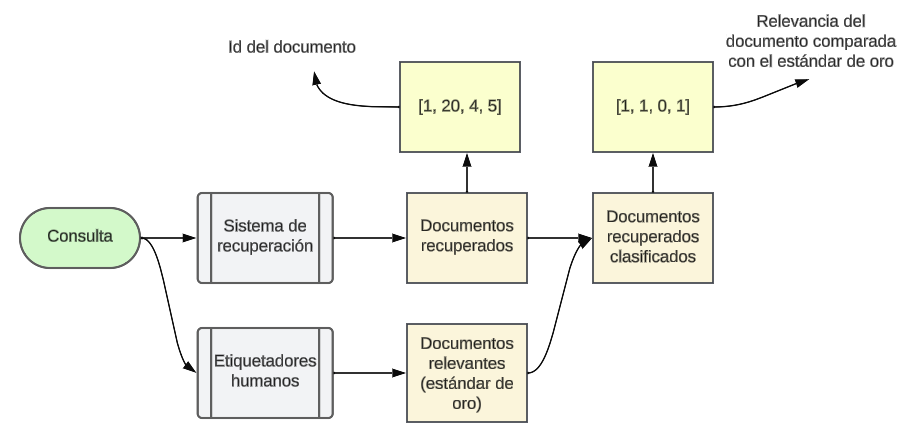

In [ ]:
def precision_at_k(classified_docs: list, k: int) -> float:
  """
  Esta función calcula la precisión hasta el k-ésimo documento. La precisión es
  la cantidad de documentos relevantes recuperados dividido por el número total
  de documentos recuperados.

  Args:
  - classified_docs: Lista de todos los documentos recuperados para determinada consulta y clasificado con el estándar de oro, en donde 1 es un documento relevante y 0
    lo contrario.
  - k: Número de documentos a tomar en cuenta en la precisión.

  Returns:
  - Precisión para los primeros k documentos recuperados.
  """

  # Implemente el cuerpo de la función guíandose por la documentación de la función provista
  ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
  # your code here
  raise NotImplementedError

In [ ]:
def recall_at_k(classified_docs: list, relevant_docs_number: int, k: int) -> float:
  """
  Esta función calcula el recall hasta el k-ésimo documento. El recall es
  la cantidad de documentos relevantes recuperados dividido por el número total
  de documentos relevantes.

  Args:
  - classified_docs: Lista de todos los documentos recuperados para determinada consulta y clasificado con el estándar de oro, en donde 1 es un documento relevante y 0
    lo contrario.
  - relevant_docs_number: Número total de documentos relevantes para la consulta según el estándar de oro.
  - k: Número de documentos a tomar en cuenta en el recall.

  Returns:
  - Recall para los primeros k documentos recuperados.
  """
  
  # Implemente el cuerpo de la función guíandose por la documentación de la función provista
  ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
  # your code here
  raise NotImplementedError

In [ ]:
def average_precision(classified_docs: list) -> float:
  """
  Esta función calcula el promedio de la precisión para todos los k posibles hasta que se recuperen todos los documentos relevantes.
  Esta función asume que los documentos en classified_docs contiene todos los documentos del corpus.

  Args:
  - classified_docs: Lista de todos los documentos recuperados para determinada consulta y clasificado con el estándar de oro, en donde 1 es un documento relevante y 0
    lo contrario.

  Returns:
  - Promedio de la precisión para todos los k posibles hasta que se recuperen todos los documentos relevantes.
  """

  # Implemente el cuerpo de la función guíandose por la documentación de la función provista
  ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
  # your code here
  raise NotImplementedError

In [ ]:
def MAP(relevance_query_group: list) -> float:
  """
  Esta función calcula el promedio de average precision para un grupo de consultas.

  Args:
  - relevance_query_group: Lista de listas de documentos recuperados para cada consulta y clasificado con el estándar de oro, en donde 1 es un documento relevante y 0
    lo contrario.

  Returns:
  - Promedio de average precision para un grupo de consultas.
  """

  # Implemente el cuerpo de la función guíandose por la documentación de la función provista
  ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
  # your code here
  raise NotImplementedError

# Explorar el dataset CISI de recuperación de información

El dataset de CISI fue extraído de Kagggle. Puede explorarlo [aquí](https://www.kaggle.com/datasets/dmaso01dsta/cisi-a-dataset-for-information-retrieval/data).
Este dataset fue públicamente distribuido por la Universidad de Glasgow. Los documentos fueron recolectados por el "Center for Inventions and Scientific Information" (CISI) y consiste en 1.460 documentos y 112 consultas asociadas.

El propósito del dataset es permitir la construcción de modelos de recuperación de información donde para cada consulta se deberían recuperar los documentos relevantes. El dataset consiste en 3 archivos:

* CISI.ALL: Archivo de texto con todos los documentos, en donde cada documento está compuesto por un id, un título, un autor, un abstract, y los documentos relacionados al documento.
* CISI.QRY: Este archivo de texto contiene 112 consultas, cada una se compone de por lo menos de un id y el texto de consulta.
* CISI.REL: Este archivo contiene el estándar de oro, y por lo tanto, relaciona los documentos relevantes para cada consulta.

En primera instancia exploraremos el contenido de cada uno de estos archivos, inicando por CISI.ALL

In [ ]:
with open('CISI_dataset/CISI.ALL') as f:
    cisi_raw_docs = f.read()

pattern = r'''(?x)    # Flag para modo verbose
    (?:\.I\s*(\d+)\s*)   # ID del documento
    (?:\.T\s*(.*?)\n\.A)   # Título
    (?:\s*(.*?)\n\.W)   # Autor
    (?:\s*(.*?)\n\.X)   # Abstract
'''

data = re.findall(pattern, cisi_raw_docs, flags=re.DOTALL)

# Para cada documento, se concatenan el título y el abstract
corpus = [d[1] + '\n' + d[3] for d in data]

Primero hacemos uso de las expresiones regulares para extraer el contenido relevante del archivo. Luego construimos nuestro corpus como un listado de documentos (texto), en donde cada documento será representado por la concatenación del título y el abstract.

A continuación se muestra el contenido del tercer documento del corpus:

In [ ]:
print(corpus[2])

In [ ]:
print(f"Número de documentos en el corpus: {len(corpus)}")

Ahora, exploraremos el archivo CISI.QRY que contiene toda la información relacionada a las consultas.

In [ ]:
with open('CISI_dataset/CISI.QRY') as f:
    queries_raw = f.read()

pattern = r'''(?x)    # Flag para modo verbose
    (?:(?:\.I)?\s*(\d+)\s*)   # ID de la consulta
    (?:.*?)?   # Ignorar contenido antes de la consulta
    (?:\.W\s*(.*?)\n\.(?:I|B))   # Consulta
'''

queries_data = re.findall(pattern, queries_raw, flags=re.DOTALL)

# Se extraen las consultas
queries = [d[1] for d in queries_data]

De este archivo solo estamos interesado en la consulta, por lo que conformamos una lista con el contenido de las mismas.

Observe el contenido de la consulta número 2:

In [ ]:
print(queries[1])

In [ ]:
print(f"Número de consultas: {len(queries)}")

Ahora, exploremos el archivo CISI.REL, que contiene el estándar de oro de documentos relevantes por cada consulta.

In [ ]:
with open('CISI_dataset/CISI.REL') as f:
    gold_standard_raw = f.readlines()

print(f"Primera fila del archivo: {gold_standard_raw[0]}")

gold_standard = [r.split()[:2] for r in gold_standard_raw] # Se toman solo los dos primeros elementos de cada fila

gold_standard[0]

De este archivo únicamente nos interesan las dos primeras columnas, que contienen la información del id de la consulta, y el id de un documento relevante para esa consulta. Utilizaremos esta información para construir un diccionario que contenga como llaves los ids de las consultas y como valores una lista de documentos relevantes para las mismas.

In [ ]:
from functools import reduce

def add_to_dict(accum, val):
    [q_id, doc_id] = val
    q_id = int(q_id) - 1 # Se resta 1 para que los índices comiencen en 0
    doc_id = int(doc_id) - 1 # Se resta 1 para que los índices comiencen en 0
    accum[q_id] = [*accum.get(q_id, []), doc_id] # Se agrega el documento a la lista de documentos relevantes para la consulta
    return accum

gold_standard = reduce(add_to_dict, gold_standard, {})

print("Número de consultas (llaves en el diccionario):", len(gold_standard))
print("Número de documentos relevantes para la primera consulta:", len(gold_standard[0]))
print("Promedio de documentos relevantes por consulta:", np.mean([len(v) for v in gold_standard.values()]))

Note que a pesar de tener 112 consultas, el estándar de oro solo contiene 76 consultas. Esto se debe a que solo se etiquetaron documentos relevantes para 76 consultas.

# Construir el sistema de recuperación de información

Ahora, vamos a constuir y evaluar un sistema simple de recuperación de información, para lo cual utilizaremos una representación de bolsa de palabras para representar cada uno de los documentos del corpus, y cada una de las consultas. Luego crearemos una función que nos permita medir, la similitud coseno entre los los vectores de documentos y los vectores de las consultas. Esta medida de similitud nos permitirá ordenar los documentos de modo que los documentos más similares a los consultas sean los primeros en nuestro sistema de recuperación. Finalmente, realizaremos la evaluación del sistema de recuperación creado.

Como primer utilizaremos CountVectorizer para realizar la transformación a bolsa de palabras.

In [ ]:
# Crear la representación de texto
text_vectorizer = CountVectorizer()

Ahora, implemente la función de similitud coseno, en donde se va a calcular la similitud de cada consulta con respecto a todos los documentos del corpus.

In [ ]:
# Cree una función para calcular la similitud coseno entre los vectores de las consultas y los vectores de los documentos
def get_cosine_similarity(query_vectors, document_vectors):
    """
    Esta función calcula la similitud coseno entre los vectores de las consultas y los vectores de los documentos.

    Args:
    - query_vectors: Matriz de vectores de las consultas (qxn) en donde q es número de consultas y n son las dimensiones de la representación de texto (para este caso sería el tamaño del vocabulario).
    - document_vectors: Matriz de vectores de los documentos (dxn) en donde d es número de documentos y n son las dimensiones de la representación de texto (para este caso sería el tamaño del vocabulario).

    Returns:
    - Matriz de similitud coseno entre las consultas y los documentos (qxd).
    """
    # Implemente el cuerpo de la función guíandose por la documentación de la función provista
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    raise NotImplementedError

# Ahora verifique que la función get_cosine_similarity funcione correctamente, recuerde que la similitud coseno para dos vectores iguales es 1 y para dos vectores ortogonales es 0
query_vectors = np.array([[1, 0, 1, 0], [0, 1, 0, 1]])
document_vectors = np.array([[1, 0, 1, 0], [0, 1, 0, 1]])

expected_result = np.array([[1., 0.], [0., 1.]]) # Para la primera consulta, el primer documento es igual a la consulta y el segundo es ortogonal. Para la segunda consulta, el primer documento es ortogonal y el segundo es igual a la consulta

actual_result = get_cosine_similarity(query_vectors, document_vectors)

print("Resultado esperado:\n", expected_result, "\n", "Resultado obtenido:\n", actual_result)

Con la función de similitud construida y la función de vectorización lista podemos construir nuestro sistema de recuperación para que ordene los documentos del corpus según la similitud con la consulta.

In [ ]:
def information_retrieval(queries, corpus, vectorizer):
    # Cree una matriz de documentos
    document_vectors = vectorizer.fit_transform(corpus).toarray()

    # Cree una matriz de consultas
    query_vectors = vectorizer.transform(queries).toarray()

    # Calcule la similitud coseno
    cosine_similarity = get_cosine_similarity(query_vectors, document_vectors)

    # Obtenga los documentos más relevantes
    sorted_docs = np.argsort(cosine_similarity)[:,::-1]

    return sorted_docs

Con el sistema de recuperación construido, puede obtener los documentos relevantes para cualquier consulta que desee.

In [ ]:
sample_query = ["What articles exist which deal with natural language processing?"]

sample_sorted_docs = information_retrieval(sample_query, corpus, text_vectorizer)

most_relevant_doc = sample_sorted_docs[0][0]

print("Documento más relevante para la consulta:")
print(corpus[most_relevant_doc])

Para poder realizar la evaluación de nuestro sistema de recuperación, necesitamos calificar la lista de documentos recuperados como relevantes o no según el estándar de oro.

In [ ]:
def check_relevance(retrieved_docs, gold_standard):
    return [[retrieved in gold_standard[q_id] for retrieved in retrieved_docs[q_id]] for q_id in gold_standard.keys()]

first_query = queries[0]
sample_sorted_docs = information_retrieval([first_query], corpus, text_vectorizer)

print("Los primeros 10 documentos recuperados para la primera consulta:", sample_sorted_docs[0][:10])

relevance = check_relevance(sample_sorted_docs, {0: gold_standard[0]})
print("Relevancia de los documentos recuperados para la primera consulta:", relevance[0][:10])

Finalmente, realicemos la evaluación de nuestro sistema de recuperación de información para el grupo de consultas para las cuales conocemos los documentos relevantes.

In [ ]:
retrieved_docs = information_retrieval(queries, corpus, text_vectorizer)
relevant_docs = check_relevance(retrieved_docs, gold_standard)

result = MAP(relevant_docs)
print(f"MAP para el conjunto de consultas: {result:.4f}")

## Mejore el desempeño del sistema de recuperación

Ahora intentaremos mejorar el desempeño del sistema mendiante la mejora del procesamiento de texto y utilizaremos la representación de texto de bolsa de palabras pero con los puntajes tf-idf.

In [ ]:
# Debe asignar a la variable text_vectorizer la instancia de TfidfVectorizer con las modificaciones necesarias para mejorar el desempeño del modelo
## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
# your code here
raise NotImplementedError

Observe como mejora el desempeño con la representación tf-idf y con el procesamiento de texto implementado. Para pasar este punto usted debe lograr un puntaje de MAP superior a 0.20.

In [ ]:
# Celda no modificable
retrieved_docs = information_retrieval(queries, corpus, text_vectorizer)
relevant_docs = check_relevance(retrieved_docs, gold_standard)

result2 = MAP(relevant_docs)
print(f"MAP para el conjunto de consultas: {result2:.4f}")